# Constructing a design matrix
DAMN relies on event times to build regressors and convolve them with basis functions. We use an object oriented approach of BasisFunctions, Regressors, and DesignMatrix. Each DesignMatrix can own multiple Regressors, each Regressor can own multiple BasisFunctions. This architecture allows for easy dot (name-based) access of regressors and their data, or numpy-like index accessing of the full design matrix. The DesignMatrix does not store a copy of the data, rather it stores pointers to the data contained in each Regressor, keeping the memory footprint low.

First, we will model a simulated neuron that responds to a stimulus presentation that occurs at random times

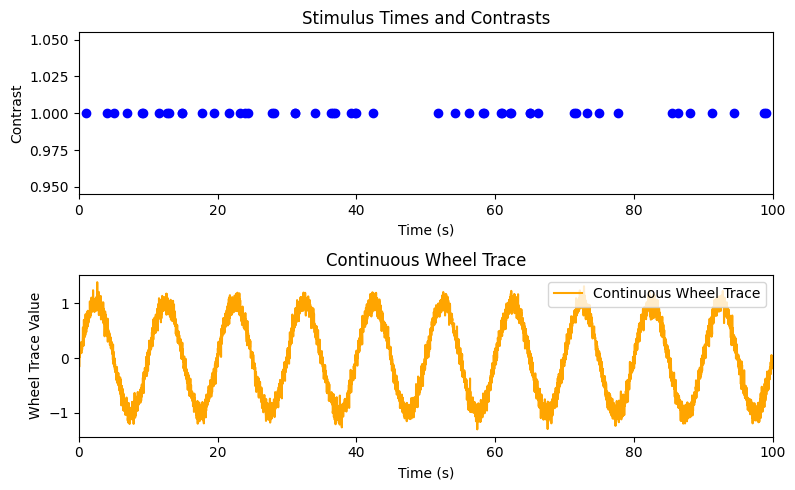

In [1]:
import numpy as np
import matplotlib.pyplot as plt
np.random.seed(42)

# simulate some data for stimulus times, contrasts, and a continuous wheel trace
nstims = 100
baseline_fr = 10
len_time = 200 # total time in seconds
stim_vals = [1,]

stim_times = np.random.uniform(0, len_time, nstims) # random stimulus times
stim_contrasts = np.random.choice(stim_vals, size=nstims) # Random contrasts for each stimulus

# simulate a continuous wheel trace too
wheel_timepoints = np.linspace(0, len_time, 10000) # Time points corresponding to the wheel trace
continuous_wheel_trace = np.sin(2 * np.pi * wheel_timepoints / 10) + 0.1 * np.random.randn(len(wheel_timepoints))

# parameters for binning the data when we eventually build the design matrix
BINWIDTH_S = 1 / 1000 # 1ms bins
PRE_S = .1
POST_S = .4

# plot the stimulus times and contrasts, as well as the wheel trace
plt.figure(figsize=(8, 5))
plt.subplot(2, 1, 1)
plt.scatter(stim_times, stim_contrasts, color='blue', label='Stimulus Times and Contrasts')
plt.xlabel('Time (s)')
plt.ylabel('Contrast')
plt.title('Stimulus Times and Contrasts')
plt.xlim(0, 100)
plt.subplot(2, 1, 2)
plt.plot(wheel_timepoints, continuous_wheel_trace, color='orange', label='Continuous Wheel Trace')
plt.xlabel('Time (s)')
plt.ylabel('Wheel Trace Value')
plt.title('Continuous Wheel Trace')
plt.xlim(0, 100)
plt.legend()
plt.tight_layout()

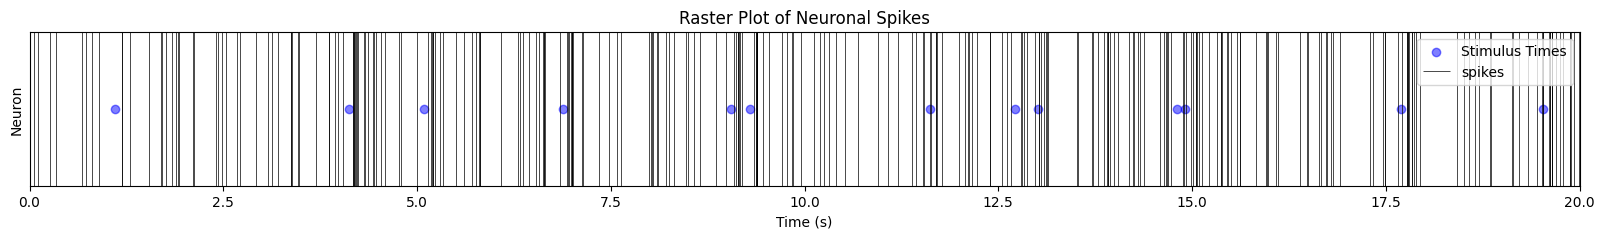

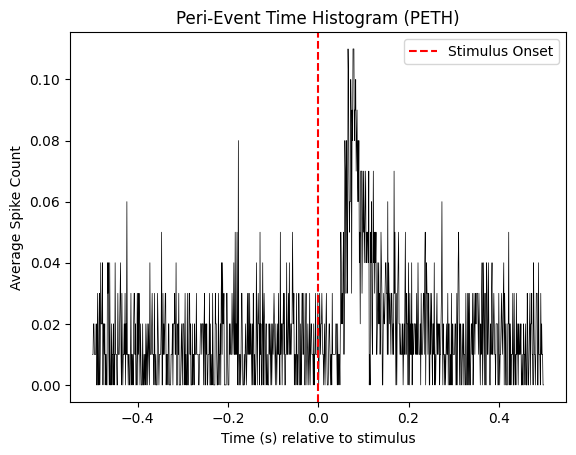

In [2]:
# create a simulated neuron that responds to the stimulus with a certain latency and amplitude
def generate_spike_times(stim_times, stim_contrasts, latency=.06, amplitude=5, baseline_hz=5):
    spike_times = []
    for stim_time, contrast in zip(stim_times, stim_contrasts):
        num_spikes = np.random.poisson(amplitude * contrast) # More spikes for higher contrast
        spikes = stim_time + (latency+np.random.normal(0,.01)) + np.random.exponential(scale=0.05, size=num_spikes) # Add some jitter to spike times
        spike_times.extend(spikes)
    spike_times = np.array(spike_times)
    # add random baseline firing rate
    baseline_spikes = np.random.uniform(0, len_time, size=int(len_time * baseline_hz)) # 5 spikes per second on average
    spike_times = np.concatenate([spike_times, baseline_spikes])
    spike_times = np.sort(spike_times)
    return spike_times
spike_times = generate_spike_times(stim_times, stim_contrasts, baseline_hz=baseline_fr)

# Plot the spike train of this unit
plt.figure(figsize=(20,2))
plt.scatter(stim_times, np.ones_like(stim_times), color='blue', label='Stimulus Times', alpha=0.5)
plt.eventplot(spike_times, lineoffsets=1, colors='black', label='spikes', linewidths=.5)
plt.xlabel('Time (s)')
plt.ylabel('Neuron')
plt.title('Raster Plot of Neuronal Spikes')
plt.ylim(1-.3, 1+.3)
plt.xlim(0, 20)
plt.legend()
plt.yticks([])
plt.show()

# plot the peth
window=(-0.5, 0.5)
bins = np.arange(window[0], window[1] + BINWIDTH_S, BINWIDTH_S)
peth = np.zeros(len(bins) - 1)
    
for stim_time in stim_times:
    aligned_spikes = spike_times - stim_time
    counts, _ = np.histogram(aligned_spikes, bins=bins)
    peth += counts
    
peth /= len(stim_times) # Normalize by number of stimuli
#plt.bar(bins[:-1], peth, width=BINWIDTH_S, color='gray', edgecolor='black')
plt.plot(bins[:-1], peth, color='k', alpha=1, linewidth=.5)
plt.xlabel('Time (s) relative to stimulus')
plt.ylabel('Average Spike Count')
plt.title('Peri-Event Time Histogram (PETH)')
plt.axvline(0, color='red', linestyle='--', label='Stimulus Onset')
plt.legend()
plt.show()


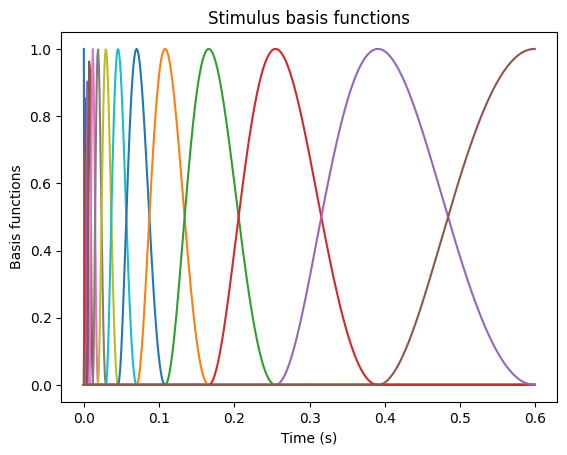

In [3]:
from damn.objects.design_matrix_objects import DesignMatrix # top level object handles all regressors
from damn.objects.regressor_objects import EventRegressor, ContinuousRegressor
from damn.objects.basis_function_objects import RaisedCosineBasis, BsplineBasis

# let's do the stimulus regressor first
# first define the basis function we will use
stim_basis_log = RaisedCosineBasis(16, 0, .6, BINWIDTH_S, log_scale=True)

stim_reg = EventRegressor(name='stimulus',
                          event_times=stim_times,
                          event_values=stim_contrasts,
                          binwidth_s=BINWIDTH_S,
                          tags=['visual', 'task_variable'],
                          basis_objects=[stim_basis_log])


plt.plot(stim_basis_log.basis_time, stim_basis_log.basis)
plt.title('Stimulus basis functions')
plt.xlabel('Time (s)')
plt.ylabel('Basis functions')
plt.show()

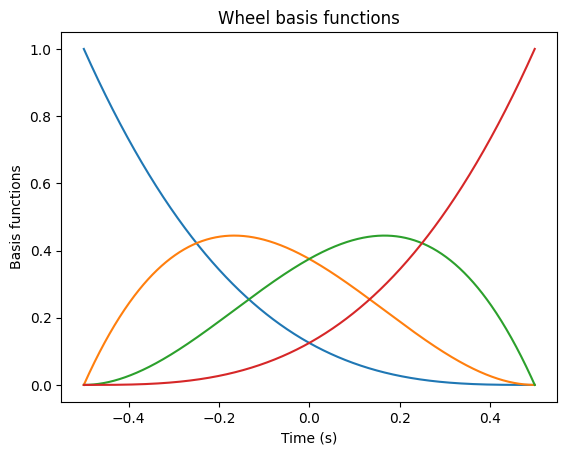

In [4]:
wheel_trace_basis = BsplineBasis(4, .5, .5, BINWIDTH_S, degree=3)

wheel_reg = ContinuousRegressor(name='wheel',
                                sample_times=wheel_timepoints, # timepoints for the trace
                                sample_values=continuous_wheel_trace, # the trace will automatically get resampled to match the design matrix time bins
                                target_binwidth_s=BINWIDTH_S,
                                zscore=True,
                                tags=['behavior'],
                                basis_objects=[wheel_trace_basis])

plt.plot(wheel_trace_basis.basis_time, wheel_trace_basis.basis)
plt.title('Wheel basis functions')
plt.xlabel('Time (s)')
plt.ylabel('Basis functions')
plt.show()

In [5]:
# now construct the design matrix to handle the time alignments of regressors

master_alignment_times = stim_times # in this case we will align everything to the stimulus times, but you could also align trials to any other event of interest (choice, feedback, etc.)

# create "trials" aligned to stimulus presentations
trialized_dmat = DesignMatrix(master_alignment_times,
                              master_pre_s=PRE_S,
                              master_post_s=POST_S,
                              binwidth_s=BINWIDTH_S)
trialized_dmat.add_regressor(stim_reg)
trialized_dmat.add_regressor(wheel_reg)

# non-trialized design matrix that just bins the entire session, generally not recommended unless ITI's are super short
non_trialized_dmat = DesignMatrix(master_alignment_times=[0],
                                  master_pre_s=0,
                                  master_post_s=np.max(stim_times),
                                  binwidth_s=BINWIDTH_S)
non_trialized_dmat.add_regressor(stim_reg)
non_trialized_dmat.add_regressor(wheel_reg)

trialized_dmat.build_matrix()
non_trialized_dmat.build_matrix()

Building regressor: "stimulus"
Building regressor: "wheel"
Building regressor: "stimulus"
Building regressor: "wheel"


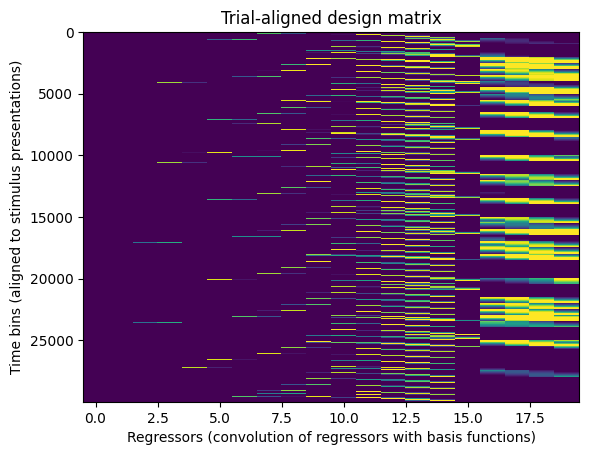

Text(0.5, 1.0, 'Non-trialized design matrix')

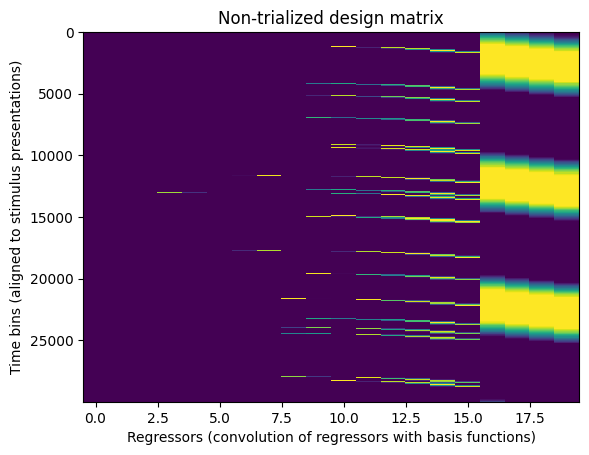

In [6]:
plt.imshow(trialized_dmat.X[:30000,], aspect='auto', interpolation='none', cmap='viridis', clim=(0,1))
plt.xlabel('Regressors (convolution of regressors with basis functions)')
plt.ylabel('Time bins (aligned to stimulus presentations)')
plt.title('Trial-aligned design matrix')
plt.show()
plt.imshow(non_trialized_dmat.X[:30000,], aspect='auto', interpolation='none', cmap='viridis', clim=(0,1))
plt.xlabel('Regressors (convolution of regressors with basis functions)')
plt.ylabel('Time bins (aligned to stimulus presentations)')
plt.title('Non-trialized design matrix')

Enabling shuffle for regressor "stimulus"


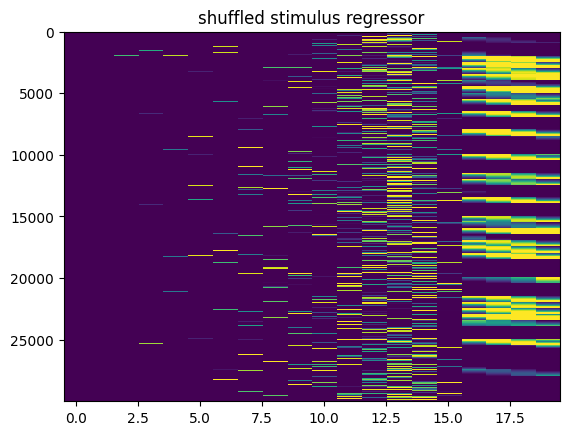

Disabling shuffle for regressor "stimulus"
Disabling shuffle for regressor "wheel"


In [7]:
# you can shuffle, zero, or completely hide regressors by their name, or their tag name
# this allows easy removing of multiple regressors at once by tagging them with the same name

trialized_dmat.set_shuffle_tags('task_variable', shuffle=True)
plt.imshow(trialized_dmat.X[:30000,], aspect='auto', interpolation='none', cmap='viridis', clim=(0,1))
plt.title('shuffled stimulus regressor')
plt.show()
trialized_dmat.unshuffle_all() # dont forget to unshuffle

In [8]:
# hiding regressors
trialized_dmat.unhide_all_regressors()
print(f'Hidden regressors: {trialized_dmat.hidden_regressors}')
trialized_dmat.remove_regressor('stimulus')
print(f'Hidden regressors: {trialized_dmat.hidden_regressors}')
trialized_dmat.unhide_all_regressors() # don't forget to unhide and unshuffle regressors

Unhiding all regressors
Hidden regressors: {}
Hidden regressors: {'stimulus': <damn.objects.regressor_objects.EventRegressor object at 0x0000023DDB65F820>}
Unhiding all regressors


In [9]:
# now bin the spikes 
from damn.alignment import compute_spike_count

Y_trialized = compute_spike_count(master_alignment_times,
                                  spike_times,
                                  PRE_S,
                                  POST_S,
                                  BINWIDTH_S)[0]
Y_trialized = Y_trialized.flatten()

Y_non_trialized = compute_spike_count([0], spike_times, 0, np.max(stim_times), BINWIDTH_S)[0].flatten()

print(Y_non_trialized.shape, Y_trialized.shape)
print(non_trialized_dmat.X.shape, trialized_dmat.X.shape)

(197378,) (49900,)
(197378, 20) (49900, 20)


In [10]:
# fit the models (trialized and non-trialized) and reconstruct the stimulus kernel for each
from scipy.ndimage import gaussian_filter1d
from sklearn.linear_model import PoissonRegressor, LinearRegression
# import deepcopy
from copy import deepcopy

mdl = PoissonRegressor(alpha=1e-12, max_iter=1000) # see notebook 2 for fitting to many neurons/regressors
mdl.fit(trialized_dmat.X, Y_trialized)
weights, bias = mdl.coef_[:,None], mdl.intercept_

trialized_dmat.set_coefficients(weights,) # This will be used to reconstruct the kernel for the stimulus regressor

# now do the same for the non-trialized design matrix
mdl_non_trialized = PoissonRegressor(alpha=1e-12, max_iter=1000)
mdl_non_trialized.fit(non_trialized_dmat.X, Y_non_trialized)
weights_non_trialized, bias_non_trialized = mdl_non_trialized.coef_[:,None], mdl_non_trialized.intercept_

non_trialized_dmat.set_coefficients(weights_non_trialized,)

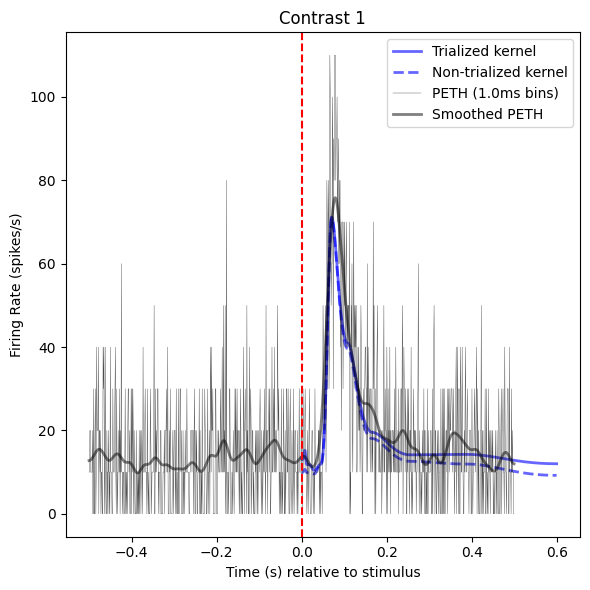

In [11]:
# replot the peth
#plt.bar(bins[:-1], peth, width=BINWIDTH_S, color='gray', edgecolor='black')
fig, axs = plt.subplots(len(stim_vals), 1, figsize=(6,6), squeeze=False)
# plot the kernels and PETHs for different stimulus values
for i,stim in enumerate(stim_vals):
    # plot the kernels
    stim_kernel_trialized, kernel_time = trialized_dmat.stimulus.reconstruct_kernel()
    stim_kernel_non_trialized, kernel_time_non_trialized = non_trialized_dmat.stimulus.reconstruct_kernel()
    stim_kernel_trialized = np.exp(stim_kernel_trialized * stim + bias)
    stim_kernel_non_trialized = np.exp(stim_kernel_non_trialized * stim + bias_non_trialized)
    axs[i,0].plot(kernel_time, stim_kernel_trialized / BINWIDTH_S, label=f'Trialized kernel', linewidth=2, color='blue',alpha=.6)
    axs[i,0].plot(kernel_time_non_trialized, stim_kernel_non_trialized / BINWIDTH_S, label='Non-trialized kernel', linewidth=2, color='blue', linestyle='--', alpha=.6)

    # plot the peth only for those contrasts
    contrast_mask = stim_contrasts == stim
    contrast_stim_times = stim_times[contrast_mask]
    contrast_peth = np.zeros(len(bins) - 1)
    for stim_time in contrast_stim_times:
        aligned_spikes = spike_times - stim_time
        counts, _ = np.histogram(aligned_spikes, bins=bins)
        contrast_peth += counts
    contrast_peth /= len(contrast_stim_times) # Normalize by number of stimuli
    contrast_spikes_per_sec = contrast_peth / BINWIDTH_S  # convert to firing rate (spikes/second)
    lab = f'PETH ({BINWIDTH_S*1000}ms bins)'
    axs[i,0].plot(bins[:-1], contrast_spikes_per_sec, color='black', alpha=0.7, label=lab, linewidth=.3)
    # plot a smoothed version of the PETH for better visualization
    contrast_peth_smoothed = gaussian_filter1d(contrast_spikes_per_sec, sigma=10)
    axs[i,0].plot(bins[:-1], contrast_peth_smoothed, color='black', alpha=.5, label=f'Smoothed PETH', linewidth=2)
    axs[i,0].set_xlabel('Time (s) relative to stimulus')
    axs[i,0].set_ylabel('Firing Rate (spikes/s)')
    axs[i,0].axvline(0, color='red', linestyle='--',)
    axs[i,0].set_title(f'Contrast {stim}')
    axs[i,0].legend()
plt.tight_layout()